# AI-Driven Network Fault Prediction & Self-Healing Platform

**End-to-end ML-powered network observability using UNSW-NB15 real dataset.**

---

### Pipeline
```
UNSW-NB15 Dataset
     |
Preprocessing & Feature Engineering
     |
Isolation Forest (Anomaly Detection)
     |
Random Forest / XGBoost (Failure Prediction)
     |
Risk Score Aggregation
     |
Graph Network Topology Analysis
     |
Self-Healing Recommendation Engine
     |
Monitoring Dashboard
```

### Modules
1. Dataset Loading (UNSW-NB15)
2. Preprocessing & Feature Engineering
3. Anomaly Detection — Isolation Forest
4. Failure Prediction — Random Forest + XGBoost
5. Model Evaluation & Explainability
6. Risk Scoring System
7. Graph Network Analysis
8. Real-Time Streaming Simulation
9. Self-Healing Recommendation Engine
10. Monitoring Dashboard
11. Model Persistence & Deployment


In [28]:
# Install required libraries (run once if needed)
# !pip install xgboost networkx scikit-learn matplotlib seaborn pandas numpy joblib pyarrow

import warnings
warnings.filterwarnings('ignore')
print("Environment ready")


Environment ready


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import joblib
import time
import random
import queue
import threading
from datetime import datetime, timedelta

from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, accuracy_score, roc_curve
)
from xgboost import XGBClassifier

sns.set_theme(style="darkgrid")
plt.rcParams.update({"figure.dpi": 130})
print("All imports successful")


All imports successful


### Dataset Loading (UNSW-NB15)

UNSW-NB15 is a real network intrusion dataset created by the Australian Centre for Cyber Security.
It contains 9 attack categories plus normal traffic with 49 raw features.

Place the files at:
- `UNSW-NB15_Dataset/UNSW_NB15_training-set.parquet`
- `UNSW-NB15_Dataset/UNSW_NB15_testing-set.parquet`

CSV versions also accepted — toggle the loader below.


In [30]:
# ---- Load UNSW-NB15 Dataset ----
# Toggle: set USE_PARQUET = False if you have CSV files instead

USE_PARQUET = True

try:
    if USE_PARQUET:
        train_data = pd.read_parquet("UNSW-NB15_Dataset/UNSW_NB15_training-set.parquet")
        test_data  = pd.read_parquet("UNSW-NB15_Dataset/UNSW_NB15_testing-set.parquet")
    else:
        train_data = pd.read_csv("UNSW-NB15_Dataset/UNSW_NB15_training-set.csv")
        test_data  = pd.read_csv("UNSW-NB15_Dataset/UNSW_NB15_testing-set.csv")

    data = train_data.copy()
    print(f"Train shape : {train_data.shape}")
    print(f"Test shape  : {test_data.shape}")
    print(f"Columns     : {list(data.columns[:10])} ...")
    data.head()

except FileNotFoundError:
    print("[INFO] UNSW-NB15 files not found. Generating synthetic fallback dataset...")
    print("[INFO] To use real data: download from https://research.unsw.edu.au/projects/unsw-nb15-dataset")

    np.random.seed(42)
    random.seed(42)
    n = 82332

    def _sim(n, fault):
        return {
            "dur":    np.random.exponential(0.5, n) + (2.0 if fault else 0),
            "sbytes": np.random.randint(100, 5000, n) * (5 if fault else 1),
            "dbytes": np.random.randint(100, 3000, n),
            "sttl":   np.random.choice([64, 128, 255], n),
            "dttl":   np.random.choice([64, 128], n),
            "sload":  np.random.uniform(0, 1e6, n) * (3 if fault else 1),
            "dload":  np.random.uniform(0, 5e5, n),
            "spkts":  np.random.randint(1, 500, n),
            "dpkts":  np.random.randint(1, 300, n),
            "sinpkt": np.random.uniform(0, 1000, n),
            "dinpkt": np.random.uniform(0, 1000, n),
            "smean":  np.random.uniform(50, 1500, n),
            "dmean":  np.random.uniform(50, 1000, n),
        }

    n_normal = int(n * 0.67)
    n_fault  = n - n_normal
    d_normal = pd.DataFrame(_sim(n_normal, False)); d_normal["label"] = 0
    d_fault  = pd.DataFrame(_sim(n_fault, True));  d_fault["label"]  = 1
    data = pd.concat([d_normal, d_fault], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

    # Mimic test set
    test_data = data.sample(frac=0.2, random_state=1).reset_index(drop=True)

    print(f"Synthetic dataset shape : {data.shape}")
    print(f"Label distribution:\n{data['label'].value_counts()}")
    data.head()


Train shape : (175341, 36)
Test shape  : (82332, 36)
Columns     : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload'] ...


### Feature Selection & Preprocessing

In [31]:
# sttl and dttl not present in this version — replaced with sjit/djit (jitter)
features = [
    "dur",
    "sbytes",
    "dbytes",
    "sload",
    "dload",
    "spkts",
    "dpkts",
    "sinpkt",
    "dinpkt",
    "sjit",
    "djit",
    "smean",
    "dmean"
]

data = data[features + ["label"]]

# Handle missing values
data = data.dropna()
data.reset_index(drop=True, inplace=True)

print(f"Shape after feature selection : {data.shape}")
print(f"Missing values                : {data.isnull().sum().sum()}")
print(f"Label distribution:\n{data['label'].value_counts()}")
data.head()


Shape after feature selection : (175341, 14)
Missing values                : 0
Label distribution:
label
1    119341
0     56000
Name: count, dtype: int64


,dur,sbytes,dbytes,sload,dload,spkts,dpkts,sinpkt,dinpkt,sjit,djit,smean,dmean,label
0,0.121478,258,172,14158.942383,8495.365234,6,4,24.295601,8.375000,30.177547,11.830604,43,43,0
1,0.649902,734,42014,8395.112305,503571.312500,14,38,49.915001,15.432865,61.426933,1387.778320,52,1106,0
2,1.623129,364,13186,1572.271851,60929.230469,8,16,231.875565,102.737206,17179.585938,11420.925781,46,824,0
3,1.681642,628,770,2740.178955,3358.622070,12,12,152.876541,90.235725,259.080170,4991.784668,52,64,0
4,0.449454,534,268,8561.499023,3987.059814,10,6,47.750332,75.659599,2415.837646,115.806999,53,45,0


### Feature Engineering

In [32]:
data["traffic_volume"] = data["sbytes"] + data["dbytes"]
data["packet_ratio"]   = data["spkts"] / (data["dpkts"] + 1)
data["load_ratio"]     = data["sload"] / (data["dload"] + 1)
data["jit_difference"] = abs(data["sjit"] - data["djit"])   # replaces ttl_difference

data["byte_ratio"]        = data["sbytes"] / (data["dbytes"] + 1)
data["pkt_mean_diff"]     = abs(data["smean"] - data["dmean"])
data["interarrival_sum"]  = data["sinpkt"] + data["dinpkt"]

print(f"Shape after feature engineering : {data.shape}")
data[["traffic_volume","packet_ratio","load_ratio","jit_difference","label"]].head()


Shape after feature engineering : (175341, 21)


,traffic_volume,packet_ratio,load_ratio,jit_difference,label
0,430,1.200000,1.666471,18.346943,0
1,42748,0.358974,0.016671,1326.351440,0
2,13550,0.470588,0.025804,5758.660156,0
3,1398,0.923077,0.815621,4732.704590,0
4,802,1.428571,2.146783,2300.030762,0


In [33]:
print(list(data.columns))

['dur', 'sbytes', 'dbytes', 'sload', 'dload', 'spkts', 'dpkts', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'smean', 'dmean', 'label', 'traffic_volume', 'packet_ratio', 'load_ratio', 'jit_difference', 'byte_ratio', 'pkt_mean_diff', 'interarrival_sum']


In [34]:
ml_features = [
    "dur", "sbytes", "dbytes",
    "sload", "dload",
    "spkts", "dpkts"
]

scaler = StandardScaler()
data[ml_features] = scaler.fit_transform(data[ml_features])

print(f"Features normalized : {len(ml_features)}")
print(f"Scaler mean sample  : {scaler.mean_[:4].round(2)}")
data[ml_features].describe().round(3)


Features normalized : 7
Scaler mean sample  : [1.36000000e+00 8.84484000e+03 1.49289200e+04 7.34540332e+07]


,dur,sbytes,dbytes,sload,dload,spkts,dpkts
count,175341.000,175341.000,175341.000,175341.000,175341.000,175341.000,175341.000
mean,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.210,-0.050,-0.104,-0.390,-0.277,-0.141,-0.172
25%,-0.210,-0.050,-0.104,-0.390,-0.277,-0.134,-0.172
50%,-0.210,-0.048,-0.103,-0.385,-0.277,-0.134,-0.154
75%,-0.107,-0.042,-0.096,0.082,-0.266,-0.061,-0.081
max,9.049,74.136,101.916,31.401,8.983,70.099,99.358


### Exploratory Data Analysis

In [35]:
ml_features = [
    "dur", "sbytes", "dbytes",
    "sload", "dload",
    "spkts", "dpkts"
]

scaler = StandardScaler()
data[ml_features] = scaler.fit_transform(data[ml_features])

print(f"Features normalized : {len(ml_features)}")
data[ml_features].describe().round(3)


Features normalized : 7


,dur,sbytes,dbytes,sload,dload,spkts,dpkts
count,175341.000,175341.000,175341.000,175341.000,175341.000,175341.000,175341.000
mean,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.210,-0.050,-0.104,-0.390,-0.277,-0.141,-0.172
25%,-0.210,-0.050,-0.104,-0.390,-0.277,-0.134,-0.172
50%,-0.210,-0.048,-0.103,-0.385,-0.277,-0.134,-0.154
75%,-0.107,-0.042,-0.096,0.082,-0.266,-0.061,-0.081
max,9.049,74.136,101.916,31.401,8.983,70.099,99.358


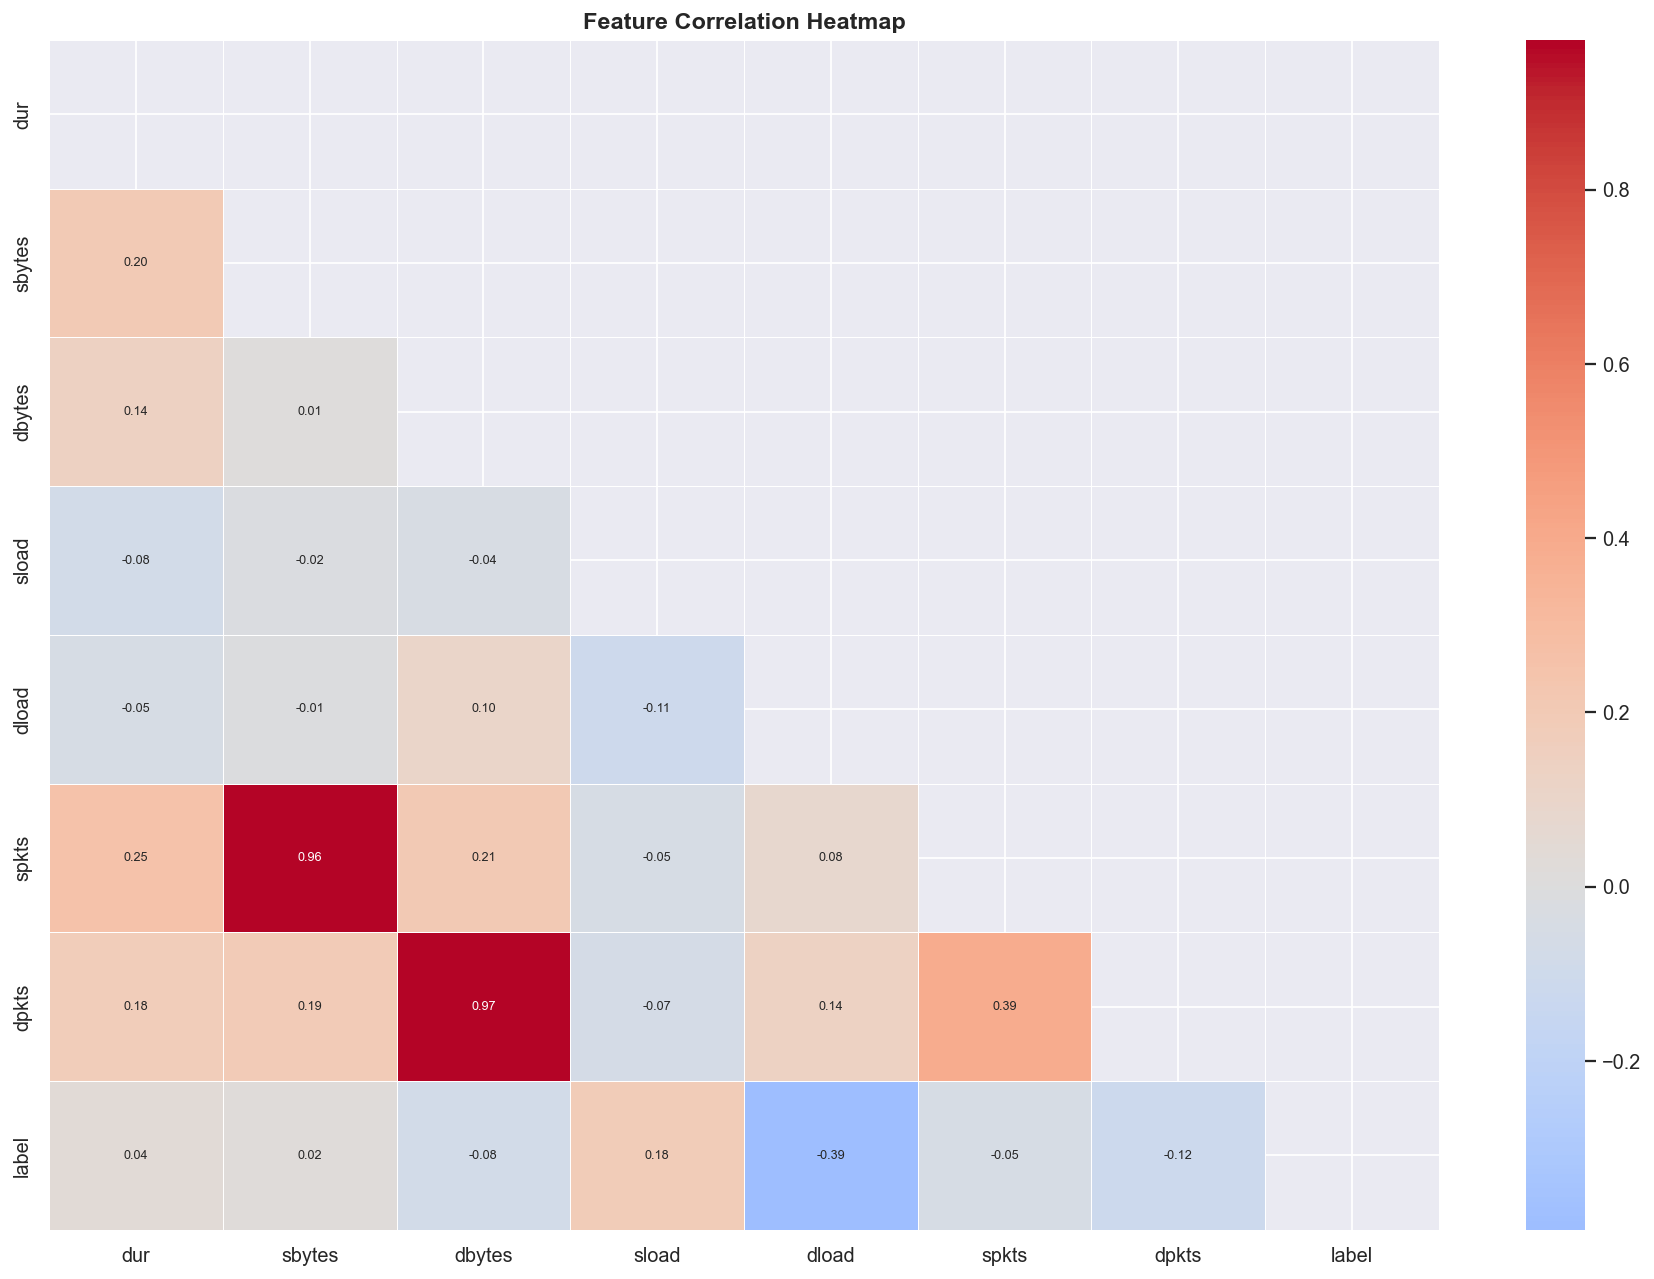

In [36]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = data[ml_features + ["label"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.4, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### Anomaly Detection (Isolation Forest + One-Class SVM)

In [37]:
# Isolation Forest
anomaly_model = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)
data["anomaly"] = anomaly_model.fit_predict(data[ml_features])
data["anomaly"] = data["anomaly"].map({1: 0, -1: 1})

# One-Class SVM on a sample (computationally heavy on full dataset)
normal_mask   = data["label"] == 0
oc_svm        = OneClassSVM(nu=0.05, kernel="rbf", gamma="auto")
oc_svm.fit(data.loc[normal_mask, ml_features].sample(min(5000, normal_mask.sum()), random_state=42))
svm_raw       = oc_svm.predict(data[ml_features])
data["anomaly_svm"] = (svm_raw == -1).astype(int)

n_anomalies_iso = data["anomaly"].sum()
n_anomalies_svm = data["anomaly_svm"].sum()
print(f"Isolation Forest anomalies detected : {n_anomalies_iso} ({n_anomalies_iso/len(data)*100:.1f}%)")
print(f"One-Class SVM anomalies detected    : {n_anomalies_svm} ({n_anomalies_svm/len(data)*100:.1f}%)")


Isolation Forest anomalies detected : 8733 (5.0%)
One-Class SVM anomalies detected    : 7957 (4.5%)


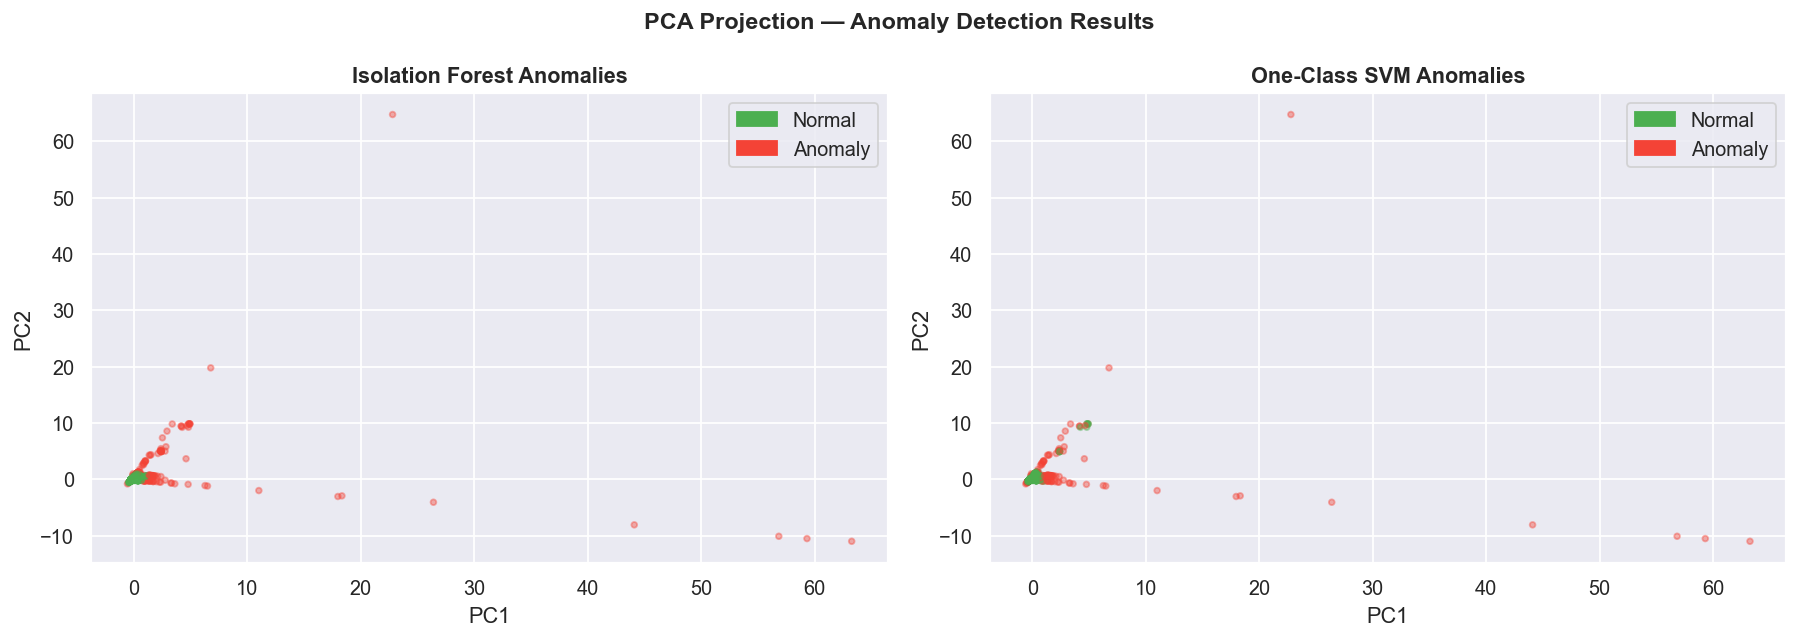

In [38]:
# PCA projection for anomaly visualization
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(data[ml_features].sample(3000, random_state=42))
lbls  = data["anomaly"].sample(3000, random_state=42).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Isolation Forest Anomalies", "One-Class SVM Anomalies"]
preds  = [
    data["anomaly"].sample(3000, random_state=42).values,
    data["anomaly_svm"].sample(3000, random_state=42).values
]

for ax, title, pred in zip(axes, titles, preds):
    colors_map = ["#4CAF50" if p == 0 else "#F44336" for p in pred]
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_map, alpha=0.4, s=10)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    patches = [
        mpatches.Patch(color="#4CAF50", label="Normal"),
        mpatches.Patch(color="#F44336", label="Anomaly")
    ]
    ax.legend(handles=patches)

plt.suptitle("PCA Projection — Anomaly Detection Results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()


### Failure Prediction (Random Forest + XGBoost)

In [39]:
X = data[ml_features]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Fault ratio in train : {y_train.mean()*100:.1f}%")


Train : (140272, 7)  |  Test : (35069, 7)
Fault ratio in train : 68.1%


In [40]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")
print(classification_report(y_test, rf_pred, target_names=["Normal", "Attack"]))


=== Random Forest ===
Accuracy : 0.9371
ROC-AUC  : 0.9874
              precision    recall  f1-score   support

      Normal       0.89      0.92      0.90     11200
      Attack       0.96      0.95      0.95     23869

    accuracy                           0.94     35069
   macro avg       0.93      0.93      0.93     35069
weighted avg       0.94      0.94      0.94     35069



In [41]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")
print(classification_report(y_test, xgb_pred, target_names=["Normal", "Attack"]))


=== XGBoost ===
Accuracy : 0.9346
ROC-AUC  : 0.9882
              precision    recall  f1-score   support

      Normal       0.87      0.94      0.90     11200
      Attack       0.97      0.93      0.95     23869

    accuracy                           0.93     35069
   macro avg       0.92      0.94      0.93     35069
weighted avg       0.94      0.93      0.94     35069



## Module 7 — Model Evaluation & Explainability

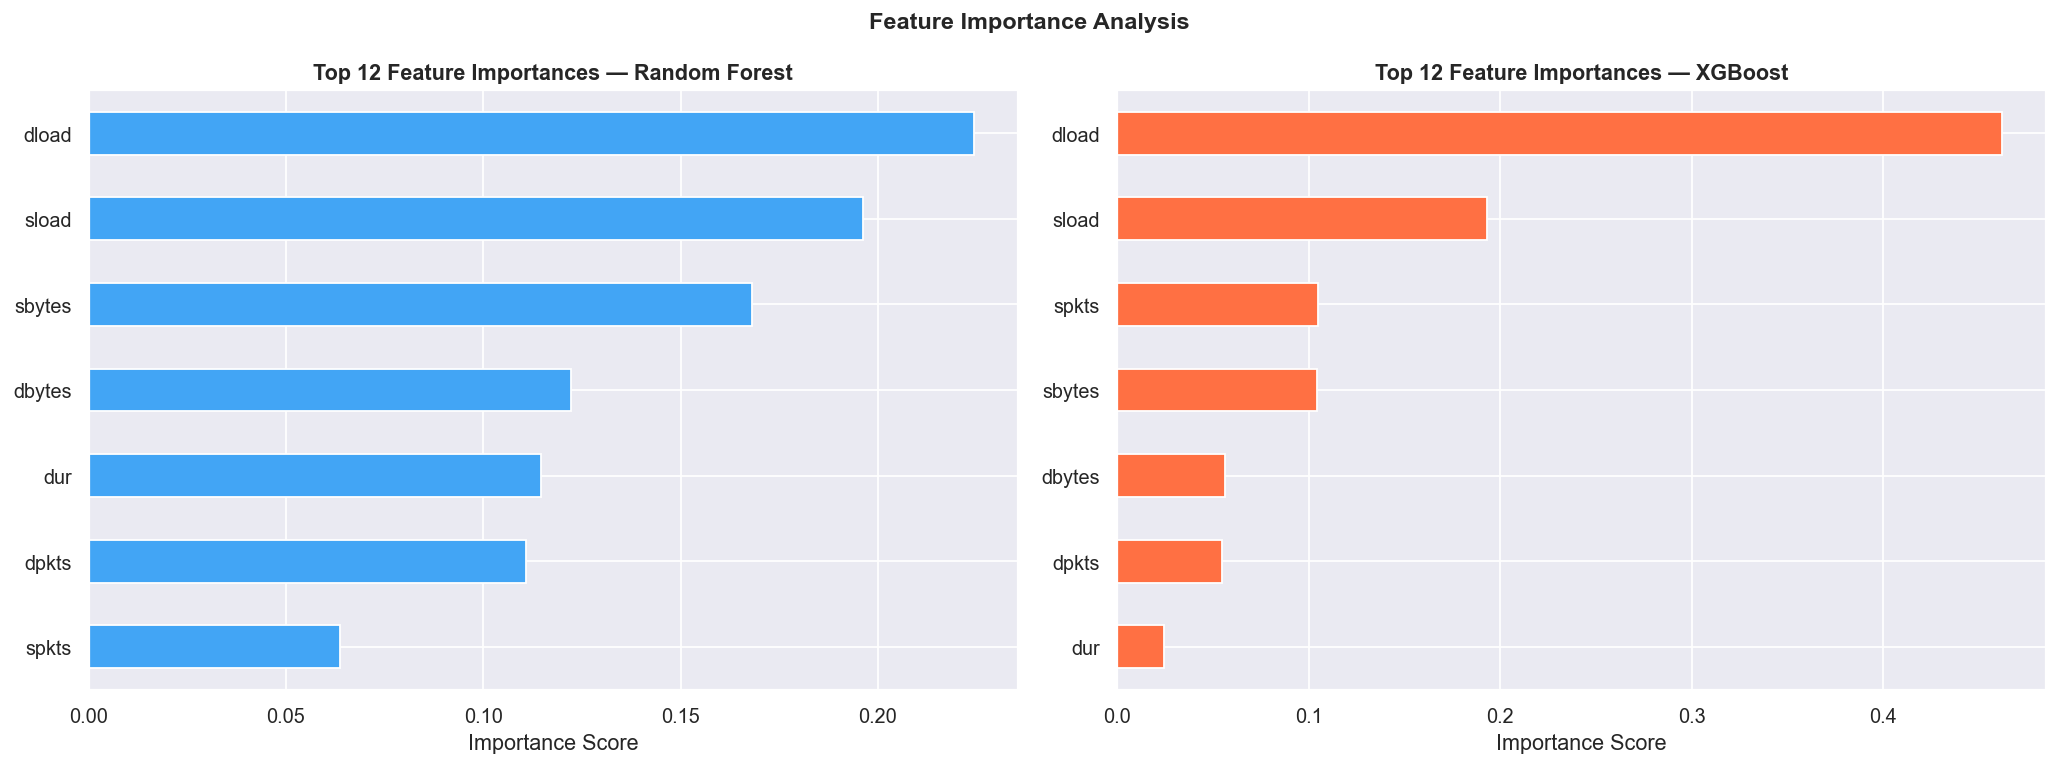

In [42]:
# Feature Importance — both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, color in zip(
        axes,
        [rf_model, xgb_model],
        ["Random Forest", "XGBoost"],
        ["#42A5F5", "#FF7043"]):
    importances = pd.Series(model.feature_importances_, index=ml_features).nlargest(12)
    importances.sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Top 12 Feature Importances — {name}", fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.suptitle("Feature Importance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


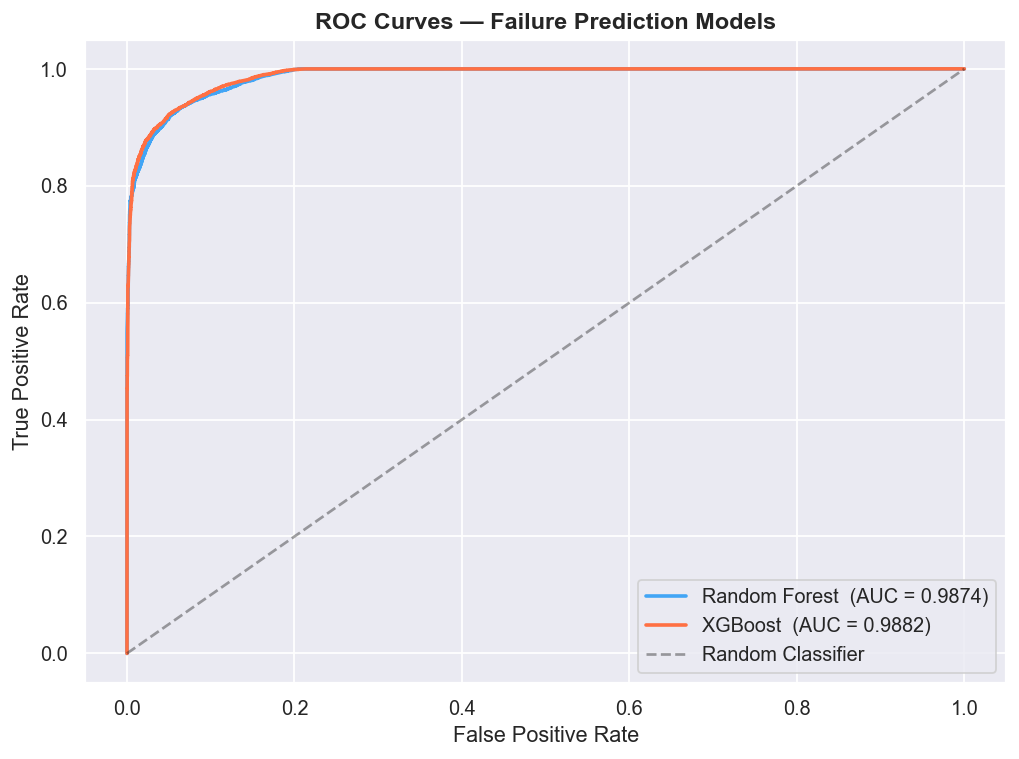

In [43]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
        ("Random Forest", rf_proba, "#42A5F5"),
        ("XGBoost",       xgb_proba, "#FF7043")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name}  (AUC = {auc:.4f})")

ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Random Classifier")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Failure Prediction Models", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


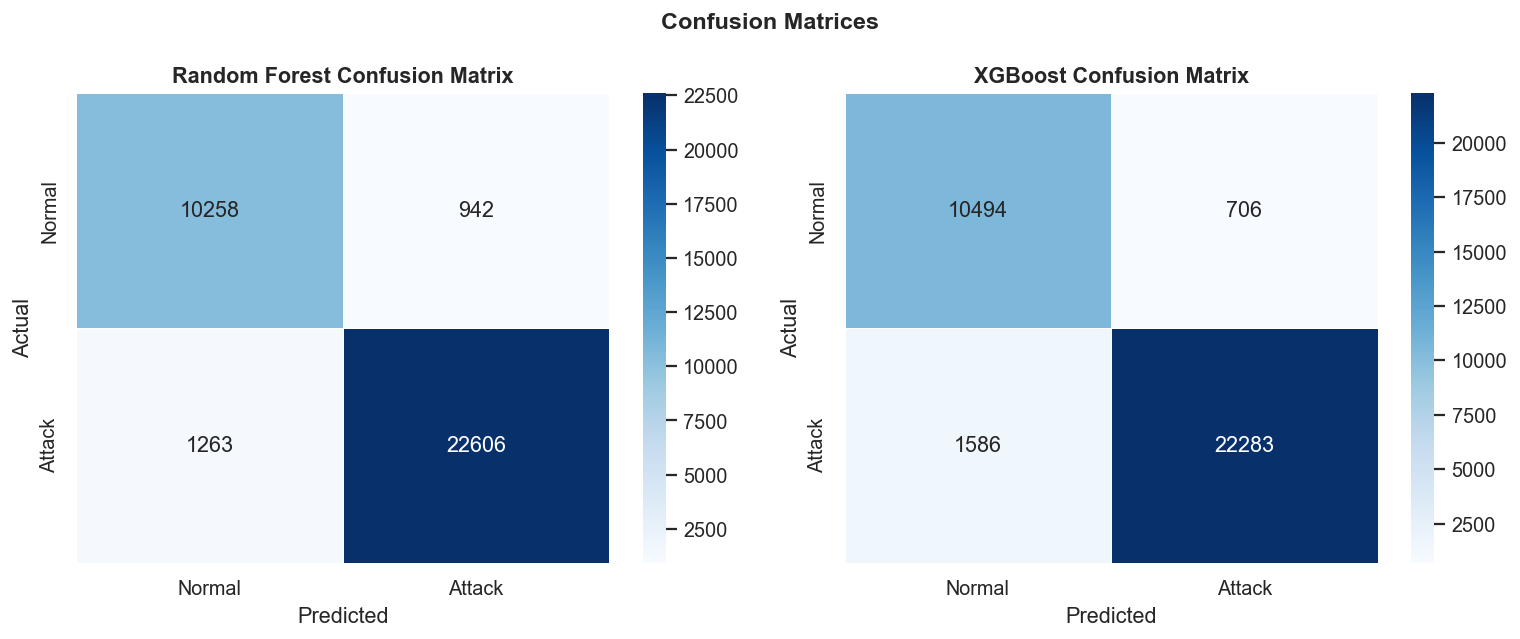

In [44]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Attack"],
                yticklabels=["Normal","Attack"],
                linewidths=0.5)
    ax.set_title(f"{name} Confusion Matrix", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


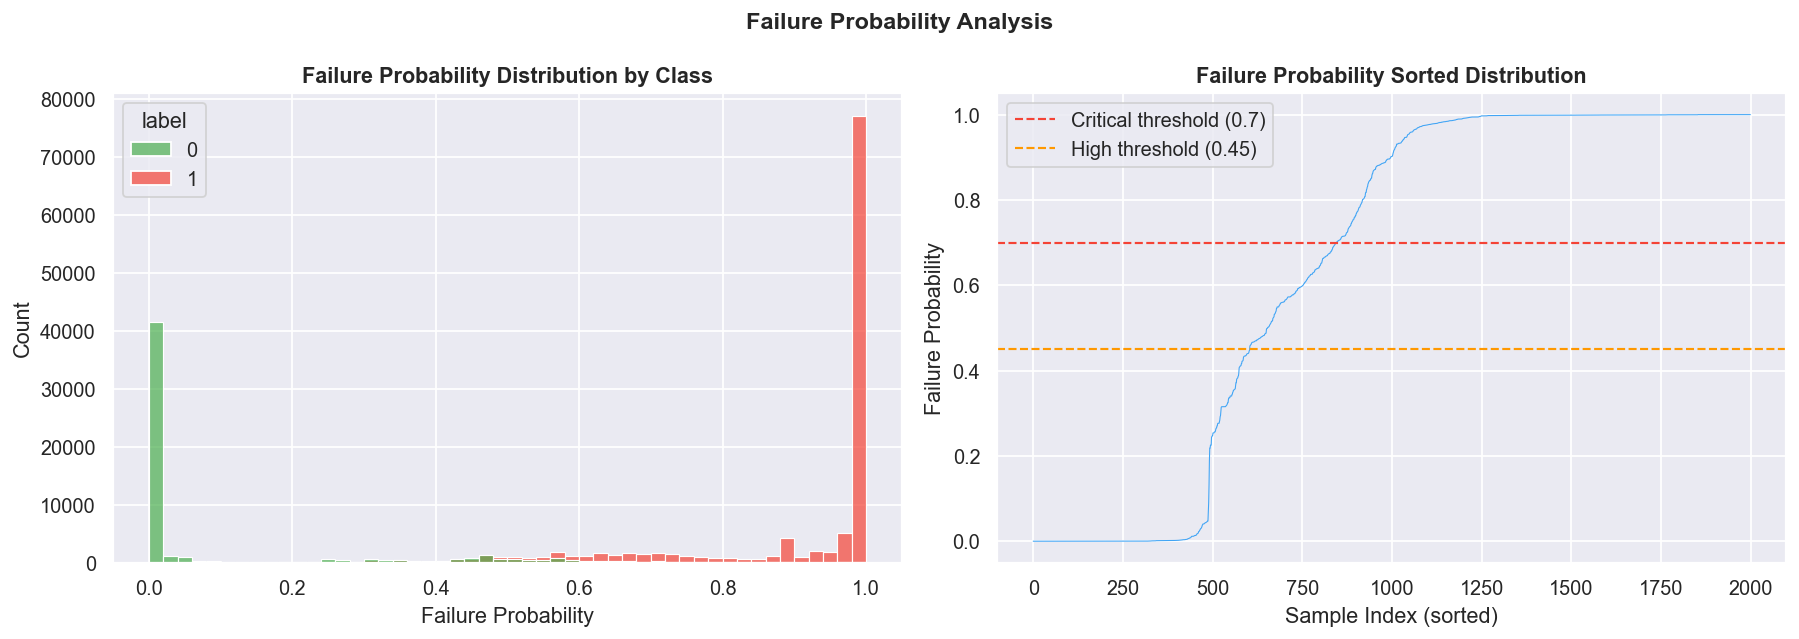

In [45]:
# Failure probability distribution
data["failure_probability"] = rf_model.predict_proba(X)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=data, x="failure_probability", hue="label",
             bins=50, ax=axes[0],
             palette={0: "#4CAF50", 1: "#F44336"}, alpha=0.7)
axes[0].set_title("Failure Probability Distribution by Class", fontweight="bold")
axes[0].set_xlabel("Failure Probability")

axes[1].plot(sorted(data["failure_probability"].sample(2000, random_state=42)), color="#42A5F5", linewidth=0.6)
axes[1].axhline(0.7, color="#F44336", linestyle="--", linewidth=1.2, label="Critical threshold (0.7)")
axes[1].axhline(0.45, color="#FF9800", linestyle="--", linewidth=1.2, label="High threshold (0.45)")
axes[1].set_title("Failure Probability Sorted Distribution", fontweight="bold")
axes[1].set_xlabel("Sample Index (sorted)"); axes[1].set_ylabel("Failure Probability")
axes[1].legend()

plt.suptitle("Failure Probability Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("failure_probability.png", dpi=150, bbox_inches="tight")
plt.show()


## Module 8 — Risk Scoring System

In [46]:
# Compute failure_probability first, then risk score
data["failure_probability"] = rf_model.predict_proba(data[ml_features])[:, 1]

# Combine anomaly detection + failure prediction
data["risk_score"] = (
    0.4 * data["anomaly"] +
    0.6 * data["failure_probability"]
).clip(0, 1)

def classify_risk(score):
    if score >= 0.70:   return "CRITICAL"
    elif score >= 0.45: return "HIGH"
    elif score >= 0.25: return "MEDIUM"
    else:               return "LOW"

data["risk_level"] = data["risk_score"].map(classify_risk)

print("Risk Level Distribution:")
print(data["risk_level"].value_counts())
print(f"\nAverage risk score : {data['risk_score'].mean():.4f}")
print(f"Max risk score     : {data['risk_score'].max():.4f}")


Risk Level Distribution:
risk_level
HIGH        93667
LOW         45711
MEDIUM      32224
CRITICAL     3739
Name: count, dtype: int64

Average risk score : 0.4072
Max risk score     : 1.0000


## Module 9 — Graph Network Topology Analysis (NetworkX)

In [47]:
np.random.seed(42)
random.seed(42)

G = nx.DiGraph()

ROUTERS  = [f"Router-{i}"  for i in range(1, 8)]
SWITCHES = [f"Switch-{i}"  for i in range(1, 5)]
SERVERS  = [f"Server-{i}"  for i in range(1, 4)]
all_nodes = ROUTERS + SWITCHES + SERVERS

# Add nodes with risk attributes derived from dataset statistics
risk_by_device = {}
for i, node in enumerate(all_nodes):
    sample_idx = np.random.choice(len(data), 50)
    node_risk  = data["risk_score"].iloc[sample_idx].mean() + np.random.uniform(-0.1, 0.1)
    node_risk  = float(np.clip(node_risk, 0.0, 1.0))
    risk_by_device[node] = node_risk
    G.add_node(node,
               risk=node_risk,
               device_type=node.split("-")[0])

# Topology edges
for r in ROUTERS[:4]:
    for r2 in ROUTERS[4:]:
        if random.random() > 0.3:
            G.add_edge(r, r2,
                       bandwidth=random.uniform(100, 1000),
                       utilization=random.uniform(0.1, 0.95))

for r in ROUTERS:
    for s in random.sample(SWITCHES, k=random.randint(1, 3)):
        G.add_edge(r, s, bandwidth=random.uniform(100, 500),
                   utilization=random.uniform(0.1, 0.9))

for s in SWITCHES:
    for srv in random.sample(SERVERS, k=random.randint(1, 2)):
        G.add_edge(s, srv, bandwidth=random.uniform(10, 100),
                   utilization=random.uniform(0.2, 0.8))

# Centrality metrics
degree_centrality = nx.degree_centrality(G)
betweenness       = nx.betweenness_centrality(G)
pagerank          = nx.pagerank(G, alpha=0.85)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("Top 5 Critical Nodes (Betweenness Centrality):")
for node in sorted(betweenness, key=betweenness.get, reverse=True)[:5]:
    print(f"  {node:12s} | Betweenness: {betweenness[node]:.3f} | PageRank: {pagerank[node]:.4f} | Risk: {risk_by_device[node]:.3f}")


Graph: 14 nodes, 27 edges
Top 5 Critical Nodes (Betweenness Centrality):
  Switch-2     | Betweenness: 0.064 | PageRank: 0.1596 | Risk: 0.434
  Switch-1     | Betweenness: 0.022 | PageRank: 0.0481 | Risk: 0.491
  Switch-4     | Betweenness: 0.019 | PageRank: 0.0730 | Risk: 0.513
  Switch-3     | Betweenness: 0.016 | PageRank: 0.0467 | Risk: 0.270
  Router-6     | Betweenness: 0.011 | PageRank: 0.0562 | Risk: 0.416


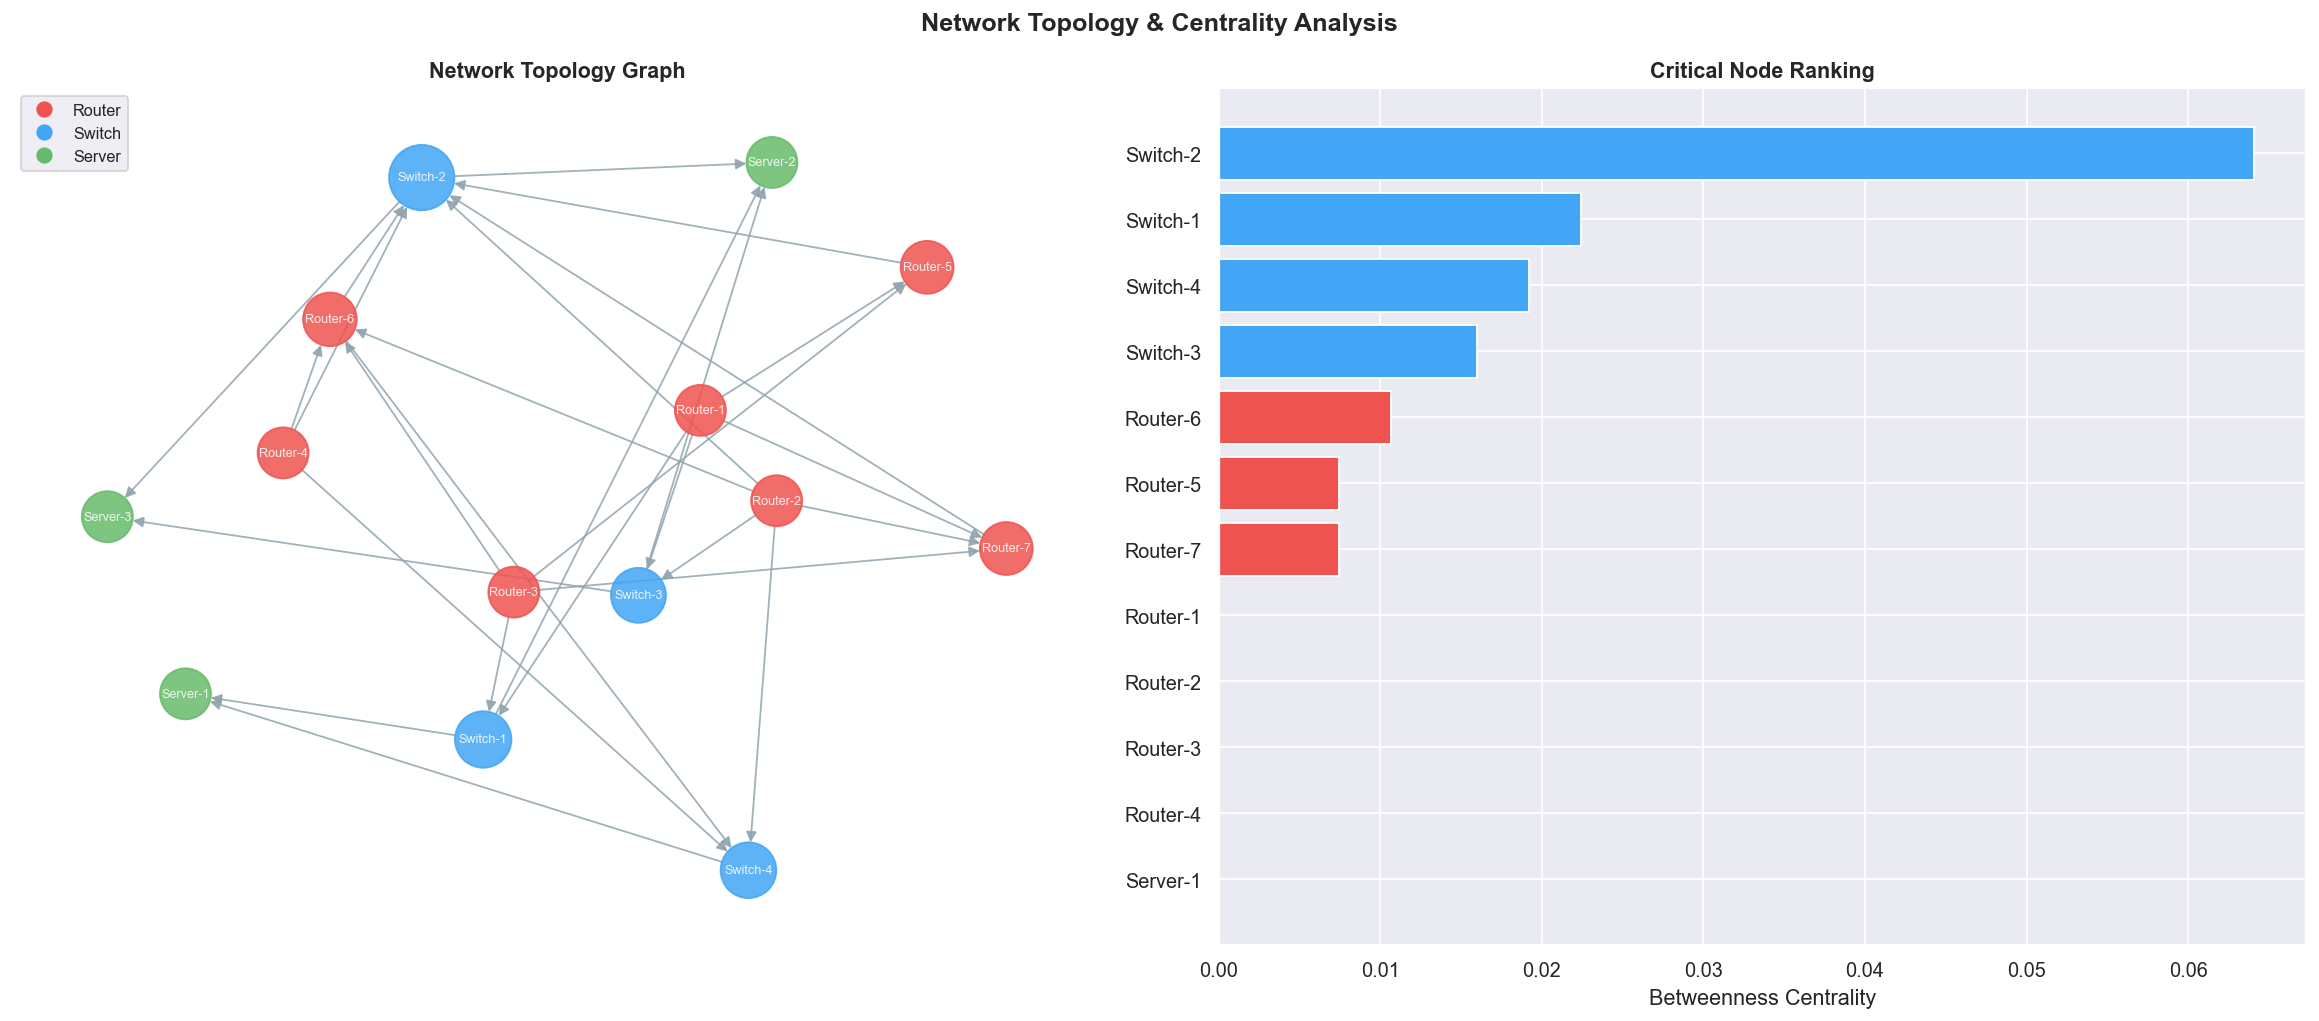

In [48]:
color_map = {"Router": "#EF5350", "Switch": "#42A5F5", "Server": "#66BB6A"}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
pos = nx.spring_layout(G, seed=42, k=1.5)

node_colors = [color_map.get(G.nodes[n]["device_type"], "#BDBDBD") for n in G.nodes]
node_sizes  = [800 + betweenness[n] * 8000 for n in G.nodes]

# Plot 1: Topology graph
ax1 = axes[0]
nx.draw_networkx(G, pos=pos, ax=ax1,
                 node_color=node_colors, node_size=node_sizes,
                 edge_color="#90A4AE", alpha=0.85,
                 arrows=True, arrowsize=12, font_size=7, font_color="white")
for dtype, col in color_map.items():
    ax1.plot([], [], "o", color=col, label=dtype, markersize=8)
ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("Network Topology Graph", fontsize=12, fontweight="bold")
ax1.axis("off")

# Plot 2: Betweenness centrality ranking
ax2 = axes[1]
sorted_bc    = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:12]
nodes_bc, vals_bc = zip(*sorted_bc)
bar_colors   = [color_map.get(n.split("-")[0], "#BDBDBD") for n in nodes_bc]
ax2.barh(list(nodes_bc), list(vals_bc), color=bar_colors)
ax2.set_xlabel("Betweenness Centrality")
ax2.set_title("Critical Node Ranking", fontsize=12, fontweight="bold")
ax2.invert_yaxis()

plt.suptitle("Network Topology & Centrality Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("network_topology.png", dpi=150, bbox_inches="tight")
plt.show()


In [49]:
# Graph-level anomaly score per node
def compute_graph_anomaly_score(node, betweenness, pagerank, risk_by_device):
    b  = betweenness.get(node, 0)
    pr = pagerank.get(node, 0)
    r  = risk_by_device.get(node, 0.3)
    return round(min(0.4 * r + 0.35 * b + 0.25 * pr, 1.0), 4)

graph_anomaly_scores = {
    node: compute_graph_anomaly_score(node, betweenness, pagerank, risk_by_device)
    for node in G.nodes
}

print("Graph Anomaly Scores (descending):")
for node, score in sorted(graph_anomaly_scores.items(), key=lambda x: x[1], reverse=True):
    bar = "|" * int(score * 30)
    print(f"  {node:12s} | {score:.4f} | {bar}")


Graph Anomaly Scores (descending):
  Switch-2     | 0.2359 | |||||||
  Switch-4     | 0.2300 | ||||||
  Switch-1     | 0.2162 | ||||||
  Server-2     | 0.2139 | ||||||
  Router-4     | 0.2045 | ||||||
  Router-3     | 0.2014 | ||||||
  Router-6     | 0.1840 | |||||
  Server-3     | 0.1833 | |||||
  Router-7     | 0.1788 | |||||
  Router-1     | 0.1735 | |||||
  Server-1     | 0.1688 | |||||
  Router-2     | 0.1472 | ||||
  Router-5     | 0.1414 | ||||
  Switch-3     | 0.1253 | |||


## Module 10 — Real-Time Streaming Simulation

In [50]:
telemetry_queue = queue.Queue(maxsize=200)
streaming_results = []

def telemetry_producer(q, n_batches=20, batch_size=10):
    for _ in range(n_batches):
        batch = data[ml_features + ["label"]].sample(batch_size, replace=True).copy()
        batch["timestamp"] = datetime.now().isoformat()
        batch["device_id"] = [random.choice(all_nodes) for _ in range(batch_size)]
        q.put(batch)
        time.sleep(0.02)
    q.put(None)

def streaming_consumer(q):
    while True:
        batch = q.get()
        if batch is None:
            break
        try:
            X_stream     = batch[ml_features]
            fail_prob    = rf_model.predict_proba(X_stream)[:, 1]
            anom_raw     = -anomaly_model.decision_function(X_stream)
            anom_norm    = (anom_raw - anom_raw.min()) / (anom_raw.max() - anom_raw.min() + 1e-9)

            batch["failure_probability"] = fail_prob
            batch["anomaly_score"]       = anom_norm
            batch["graph_anom_score"]    = batch["device_id"].map(
                lambda d: graph_anomaly_scores.get(d, 0.1))
            batch["risk_score"] = (
                0.4 * batch["anomaly_score"] +
                0.4 * batch["failure_probability"] +
                0.2 * batch["graph_anom_score"]
            ).clip(0, 1)
            streaming_results.append(batch)
        except Exception as e:
            print(f"Inference error: {e}")
        q.task_done()

producer_t = threading.Thread(target=telemetry_producer, args=(telemetry_queue, 20, 10))
consumer_t = threading.Thread(target=streaming_consumer, args=(telemetry_queue,))
producer_t.start(); consumer_t.start()
producer_t.join(); consumer_t.join()

df_stream = pd.concat(streaming_results, ignore_index=True)
print(f"Streamed and processed {len(df_stream)} records")

# Live console output style
print("Sample predictions:")
print(f"{'Device':<14} {'Fail Prob':>10} {'Anom Score':>12} {'Risk Score':>12}")
print("-" * 52)
for _, row in df_stream.sample(10, random_state=42).iterrows():
    print(f"{row['device_id']:<14} {row['failure_probability']:>10.4f} {row['anomaly_score']:>12.4f} {row['risk_score']:>12.4f}")


Streamed and processed 200 records
Sample predictions:
Device          Fail Prob   Anom Score   Risk Score
----------------------------------------------------
Switch-4           0.0000       0.6785       0.3174
Router-2           0.6725       0.0905       0.3346
Server-1           0.9986       0.0000       0.4332
Server-1           0.9996       0.0000       0.4336
Router-4           0.9986       0.1534       0.5017
Switch-4           0.9460       0.2348       0.5183
Switch-1           0.9986       0.0814       0.4752
Router-3           0.0201       0.4060       0.2107
Server-3           0.9996       0.0000       0.4365
Router-3           0.0027       0.0675       0.0684


## Module 11 — Self-Healing Recommendation Engine

In [51]:
HEALING_RULES = [
    {
        "name": "critical_failure_risk",
        "condition": lambda r: r["failure_probability"] > 0.80,
        "issue": "Critical failure probability threshold exceeded",
        "actions": [
            "Reroute traffic to backup path immediately",
            "Trigger automated device failover sequence",
            "Alert NOC team for manual inspection",
            "Initiate graceful service migration"
        ]
    },
    {
        "name": "anomaly_detected",
        "condition": lambda r: r["anomaly"] == 1,
        "issue": "Behavioral anomaly detected — possible intrusion or hardware fault",
        "actions": [
            "Inspect network flow logs for anomalous patterns",
            "Cross-check against known attack signatures",
            "Isolate device from production VLAN if confirmed",
            "Run deep packet inspection on affected interface"
        ]
    },
    {
        "name": "high_traffic_volume",
        "condition": lambda r: r.get("traffic_volume", 0) > 1.5,
        "issue": "Traffic volume spike — potential DDoS or broadcast storm",
        "actions": [
            "Apply rate limiting on ingress interface",
            "Enable traffic scrubbing via upstream provider",
            "Activate QoS policy to protect critical flows"
        ]
    },
    {
        "name": "high_packet_ratio",
        "condition": lambda r: r.get("packet_ratio", 0) > 2.0,
        "issue": "Asymmetric packet ratio — possible SYN flood or scanning",
        "actions": [
            "Enable SYN cookie protection on border routers",
            "Block suspicious source IPs at ACL level",
            "Tune firewall stateful inspection thresholds"
        ]
    },
]

def generate_recommendations(record):
    triggered = []
    for rule in HEALING_RULES:
        try:
            if rule["condition"](record):
                triggered.append({"issue": rule["issue"], "actions": rule["actions"]})
        except Exception:
            pass
    return triggered

# Augment df_stream with anomaly flag
df_stream["anomaly"] = anomaly_model.predict(df_stream[ml_features])
df_stream["anomaly"] = df_stream["anomaly"].map({1: 0, -1: 1})

top_alerts = df_stream.nlargest(6, "risk_score")

print("=" * 68)
print("  SELF-HEALING RECOMMENDATION ENGINE  —  ACTIVE ALERTS")
print("=" * 68)

for _, row in top_alerts.iterrows():
    level = "CRITICAL" if row["risk_score"] >= 0.70 else "HIGH"
    print(f"Device   : {row['device_id']}")
    print(f"Risk     : {row['risk_score']:.4f}  [{level}]")
    print(f"Fail Prob: {row['failure_probability']:.4f}  |  Anomaly: {int(row['anomaly'])}")

    recs = generate_recommendations(row)
    if recs:
        for rec in recs:
            print(f"Issue   : {rec['issue']}")
            for action in rec["actions"]:
                print(f"  Action  -> {action}")
    else:
        print("  Status  : No critical rule triggered. Continue standard monitoring.")
    print("-" * 68)


  SELF-HEALING RECOMMENDATION ENGINE  —  ACTIVE ALERTS
Device   : Router-4
Risk     : 0.8407  [CRITICAL]
Fail Prob: 0.9996  |  Anomaly: 1
Issue   : Critical failure probability threshold exceeded
  Action  -> Reroute traffic to backup path immediately
  Action  -> Trigger automated device failover sequence
  Action  -> Alert NOC team for manual inspection
  Action  -> Initiate graceful service migration
Issue   : Behavioral anomaly detected — possible intrusion or hardware fault
  Action  -> Inspect network flow logs for anomalous patterns
  Action  -> Cross-check against known attack signatures
  Action  -> Isolate device from production VLAN if confirmed
  Action  -> Run deep packet inspection on affected interface
--------------------------------------------------------------------
Device   : Router-3
Risk     : 0.8401  [CRITICAL]
Fail Prob: 0.9996  |  Anomaly: 1
Issue   : Critical failure probability threshold exceeded
  Action  -> Reroute traffic to backup path immediately
  Actio

In [52]:
# Vectorized recommendation column on full dataset
def recommendation_label(row):
    if row["failure_probability"] > 0.80:
        return "HIGH RISK: reroute traffic or trigger failover"
    if row.get("anomaly", 0) == 1:
        return "ANOMALY: inspect network logs and isolate if confirmed"
    if row["risk_score"] >= 0.45:
        return "ELEVATED RISK: increase monitoring frequency"
    return "NORMAL: system operating within expected parameters"

data["recommendation"] = data.apply(recommendation_label, axis=1)

print("Recommendation distribution:")
print(data["recommendation"].value_counts())


Recommendation distribution:
recommendation
HIGH RISK: reroute traffic or trigger failover            94445
NORMAL: system operating within expected parameters       73102
ANOMALY: inspect network logs and isolate if confirmed     5487
ELEVATED RISK: increase monitoring frequency               2307
Name: count, dtype: int64


## Module 12 — Network Monitoring Dashboard

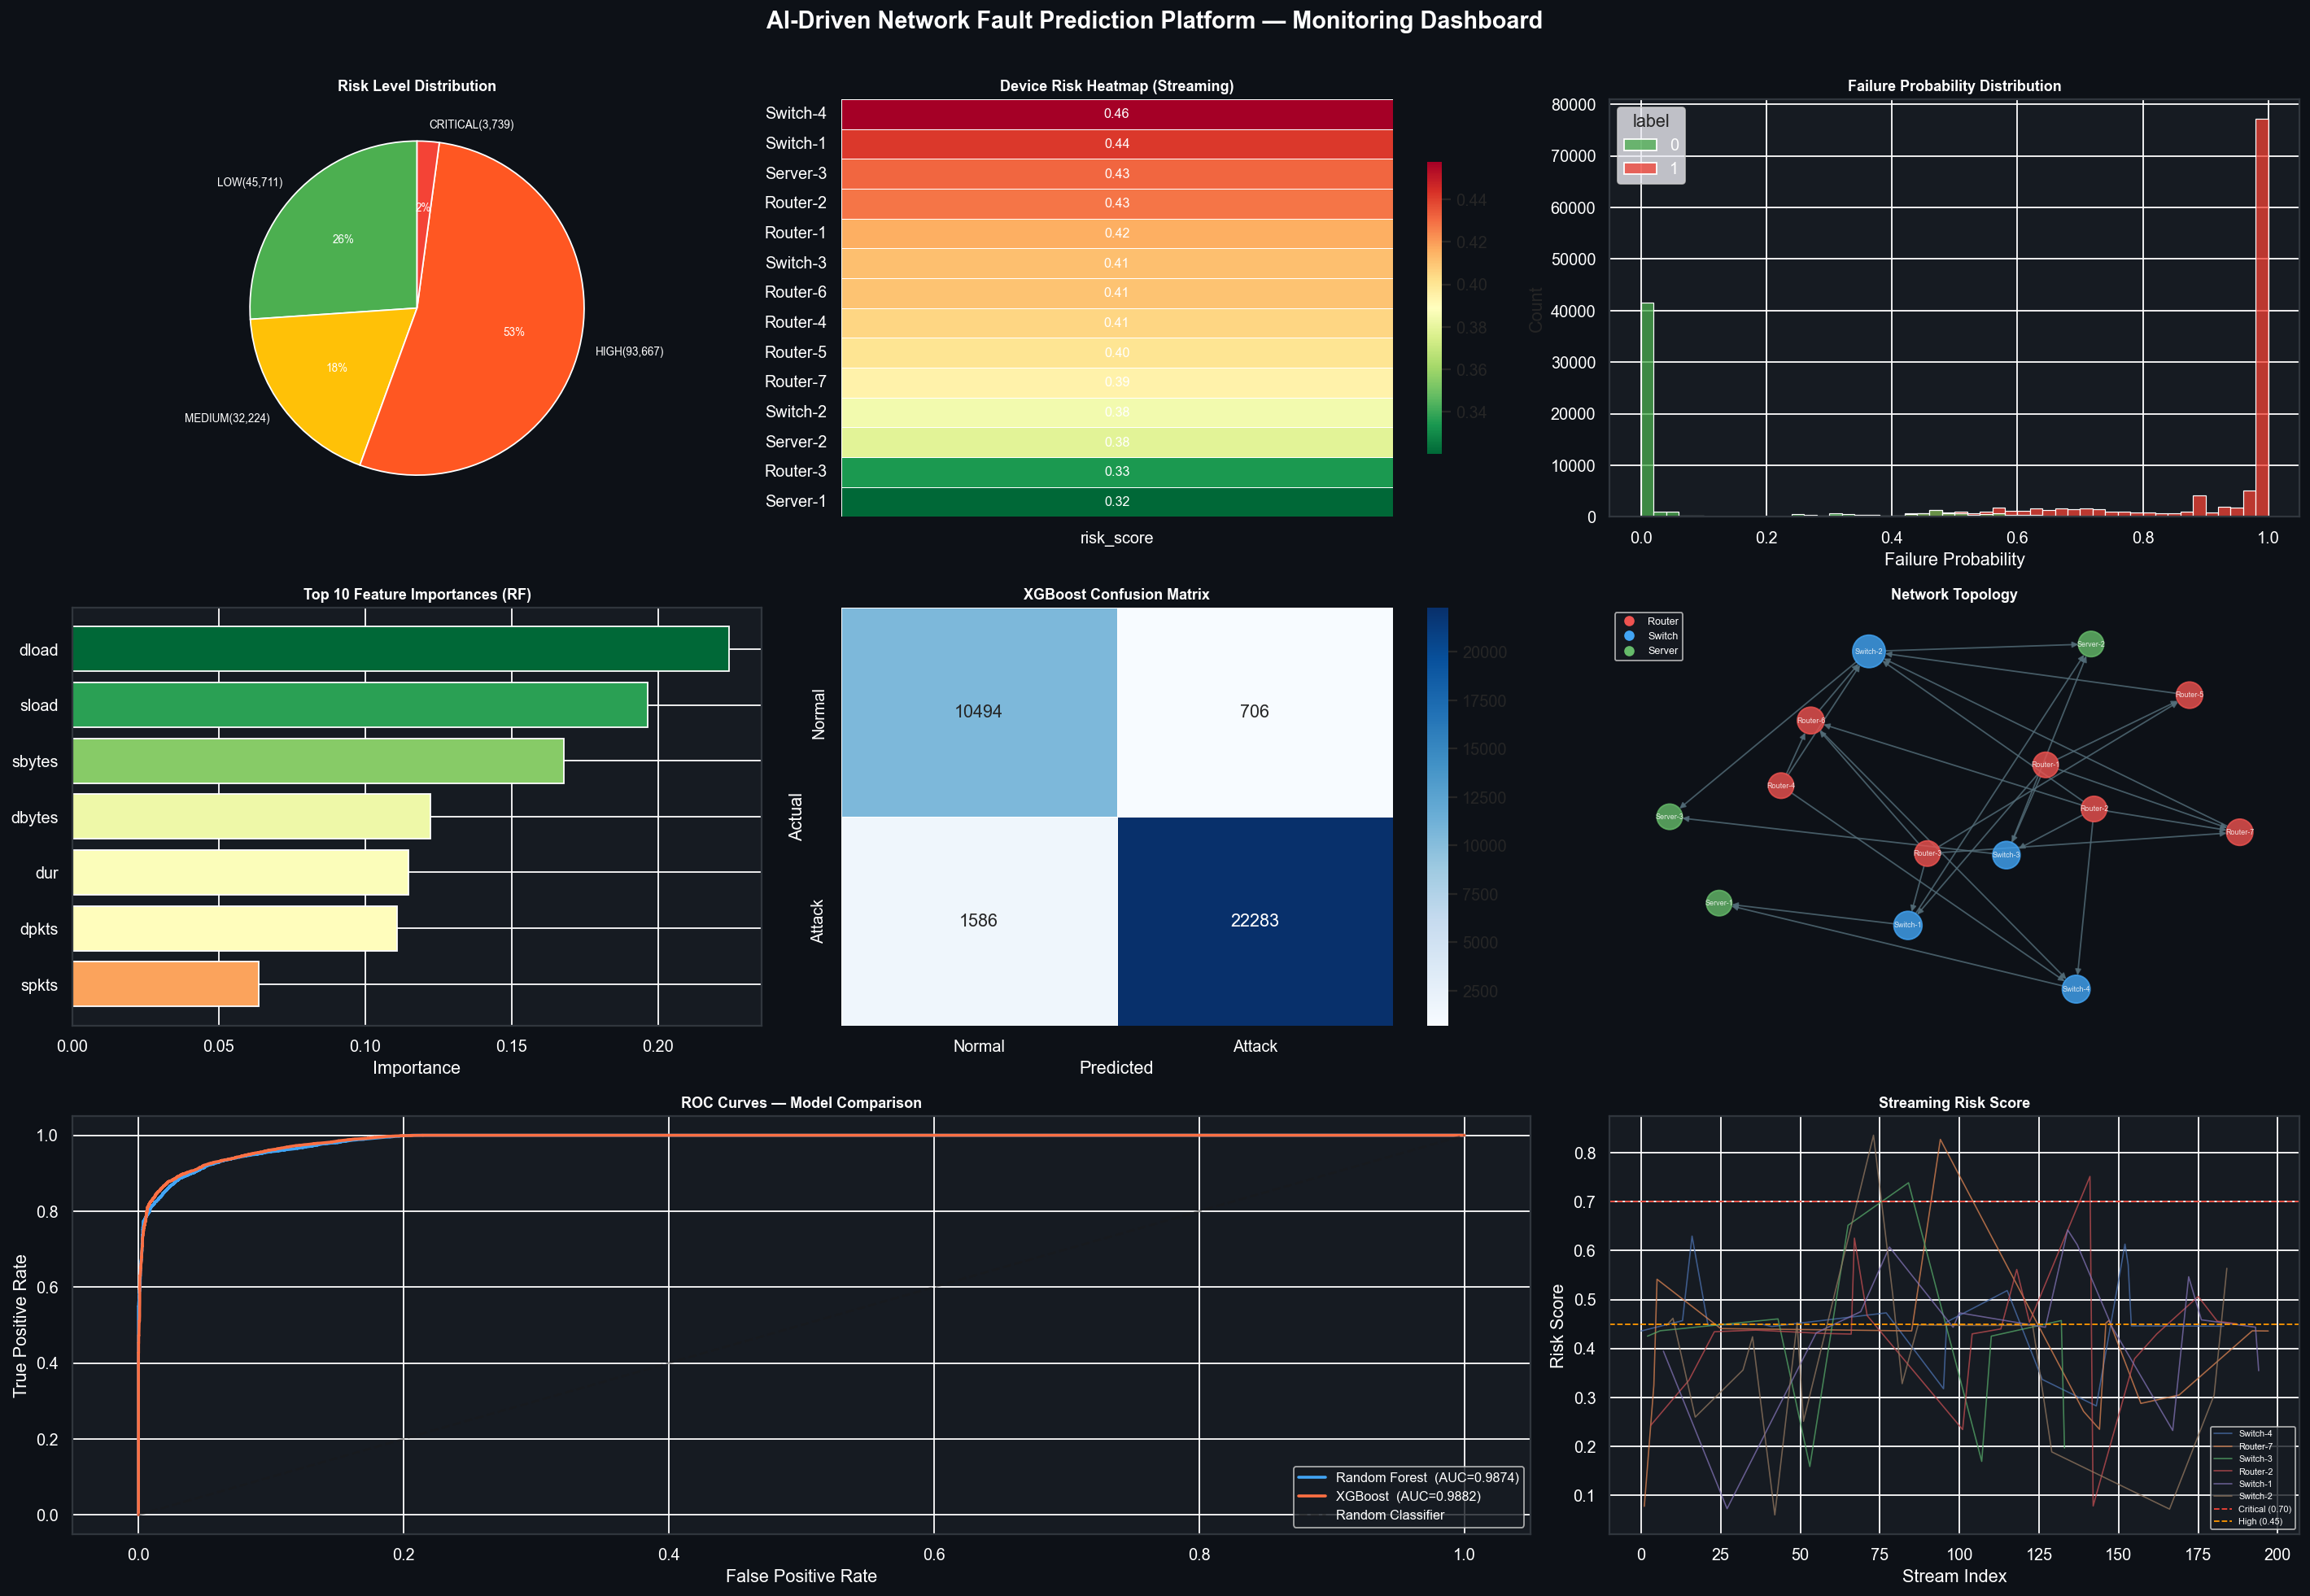

Dashboard rendered and saved


In [53]:
DARK_BG = "#0d1117"
CARD_BG = "#161b22"

fig = plt.figure(figsize=(22, 15))
fig.patch.set_facecolor(DARK_BG)

# 1. Risk distribution pie
ax1 = fig.add_subplot(3, 3, 1)
ax1.set_facecolor(CARD_BG)
risk_order  = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
risk_colors = ["#4CAF50", "#FFC107", "#FF5722", "#F44336"]
risk_counts = data["risk_level"].value_counts()
pie_vals = [risk_counts.get(k, 0) for k in risk_order]
pie_lbls = [f"{k}({v:,})" for k, v in zip(risk_order, pie_vals)]
ax1.pie(pie_vals, labels=pie_lbls, colors=risk_colors, startangle=90,
        autopct="%1.0f%%", textprops={"color": "white", "fontsize": 7.5})
ax1.set_title("Risk Level Distribution", color="white", fontsize=10, fontweight="bold")

# 2. Top 10 risky feature rows heatmap (device-level from stream)
ax2 = fig.add_subplot(3, 3, 2)
ax2.set_facecolor(CARD_BG)
pivot = df_stream.groupby("device_id")["risk_score"].mean().sort_values(ascending=False).to_frame()
sns.heatmap(pivot, ax=ax2, cmap="RdYlGn_r", annot=True, fmt=".2f",
            cbar_kws={"shrink": 0.7}, linewidths=0.5,
            annot_kws={"color": "white", "size": 9})
ax2.set_title("Device Risk Heatmap (Streaming)", color="white", fontsize=10, fontweight="bold")
ax2.tick_params(colors="white"); ax2.set_xlabel(""); ax2.set_ylabel("")

# 3. Failure probability histogram
ax3 = fig.add_subplot(3, 3, 3)
ax3.set_facecolor(CARD_BG)
sns.histplot(data=data, x="failure_probability", hue="label",
             bins=50, ax=ax3, palette={0: "#4CAF50", 1: "#F44336"}, alpha=0.75)
ax3.set_title("Failure Probability Distribution", color="white", fontsize=10, fontweight="bold")
ax3.set_xlabel("Failure Probability", color="white")
ax3.tick_params(colors="white")
ax3.get_legend().get_texts()[0].set_color("white")
ax3.get_legend().get_texts()[1].set_color("white")

# 4. Feature importance (RF)
ax4 = fig.add_subplot(3, 3, 4)
ax4.set_facecolor(CARD_BG)
importances = pd.Series(rf_model.feature_importances_, index=ml_features).nlargest(10).sort_values()
bar_colors  = plt.cm.RdYlGn(importances.values / importances.max())
ax4.barh(importances.index, importances.values, color=bar_colors)
ax4.set_title("Top 10 Feature Importances (RF)", color="white", fontsize=10, fontweight="bold")
ax4.set_xlabel("Importance", color="white"); ax4.tick_params(colors="white")

# 5. Confusion matrix (XGBoost)
ax5 = fig.add_subplot(3, 3, 5)
ax5.set_facecolor(CARD_BG)
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax5,
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"],
            linewidths=0.5)
ax5.set_title("XGBoost Confusion Matrix", color="white", fontsize=10, fontweight="bold")
ax5.tick_params(colors="white")
ax5.set_xlabel("Predicted", color="white"); ax5.set_ylabel("Actual", color="white")

# 6. Network topology
ax6 = fig.add_subplot(3, 3, 6)
ax6.set_facecolor(CARD_BG)
nc = [color_map.get(G.nodes[n]["device_type"], "#BDBDBD") for n in G.nodes]
ns = [300 + betweenness[n] * 3000 for n in G.nodes]
nx.draw_networkx(G, pos=pos, ax=ax6, node_color=nc, node_size=ns,
                 edge_color="#546E7A", alpha=0.8, font_size=5,
                 arrows=True, arrowsize=8, font_color="white")
for dtype, col in color_map.items():
    ax6.plot([], [], "o", color=col, label=dtype, markersize=6)
ax6.legend(loc="upper left", fontsize=7, facecolor=CARD_BG, labelcolor="white")
ax6.set_title("Network Topology", color="white", fontsize=10, fontweight="bold")
ax6.axis("off")

# 7. ROC curves (bottom row span 2)
ax7 = fig.add_subplot(3, 3, (7, 8))
ax7.set_facecolor(CARD_BG)
for name, proba, color in [("Random Forest", rf_proba, "#42A5F5"), ("XGBoost", xgb_proba, "#FF7043")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax7.plot(fpr, tpr, color=color, linewidth=2, label=f"{name}  (AUC={auc:.4f})")
ax7.plot([0,1],[0,1],"k--", alpha=0.4, label="Random Classifier")
ax7.set_xlabel("False Positive Rate", color="white")
ax7.set_ylabel("True Positive Rate", color="white")
ax7.set_title("ROC Curves — Model Comparison", color="white", fontsize=10, fontweight="bold")
ax7.legend(facecolor=CARD_BG, labelcolor="white", fontsize=9)
ax7.tick_params(colors="white")

# 8. Streaming risk score over time
ax8 = fig.add_subplot(3, 3, 9)
ax8.set_facecolor(CARD_BG)
df_stream["idx"] = range(len(df_stream))
for device in df_stream["device_id"].unique()[:6]:
    sub = df_stream[df_stream["device_id"] == device]
    ax8.plot(sub["idx"], sub["risk_score"], alpha=0.75, linewidth=0.9, label=device)
ax8.axhline(0.70, color="#F44336", linestyle="--", linewidth=1, label="Critical (0.70)")
ax8.axhline(0.45, color="#FF9800", linestyle="--", linewidth=1, label="High (0.45)")
ax8.set_title("Streaming Risk Score", color="white", fontsize=10, fontweight="bold")
ax8.set_xlabel("Stream Index", color="white"); ax8.set_ylabel("Risk Score", color="white")
ax8.tick_params(colors="white")
ax8.legend(fontsize=6, facecolor=CARD_BG, labelcolor="white")

for ax in fig.get_axes():
    ax.set_facecolor(CARD_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

fig.suptitle("AI-Driven Network Fault Prediction Platform — Monitoring Dashboard",
             fontsize=16, fontweight="bold", color="white", y=1.005)
plt.tight_layout()
plt.savefig("monitoring_dashboard.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Dashboard rendered and saved")


## Module 13 — Correlation & Distribution Analysis

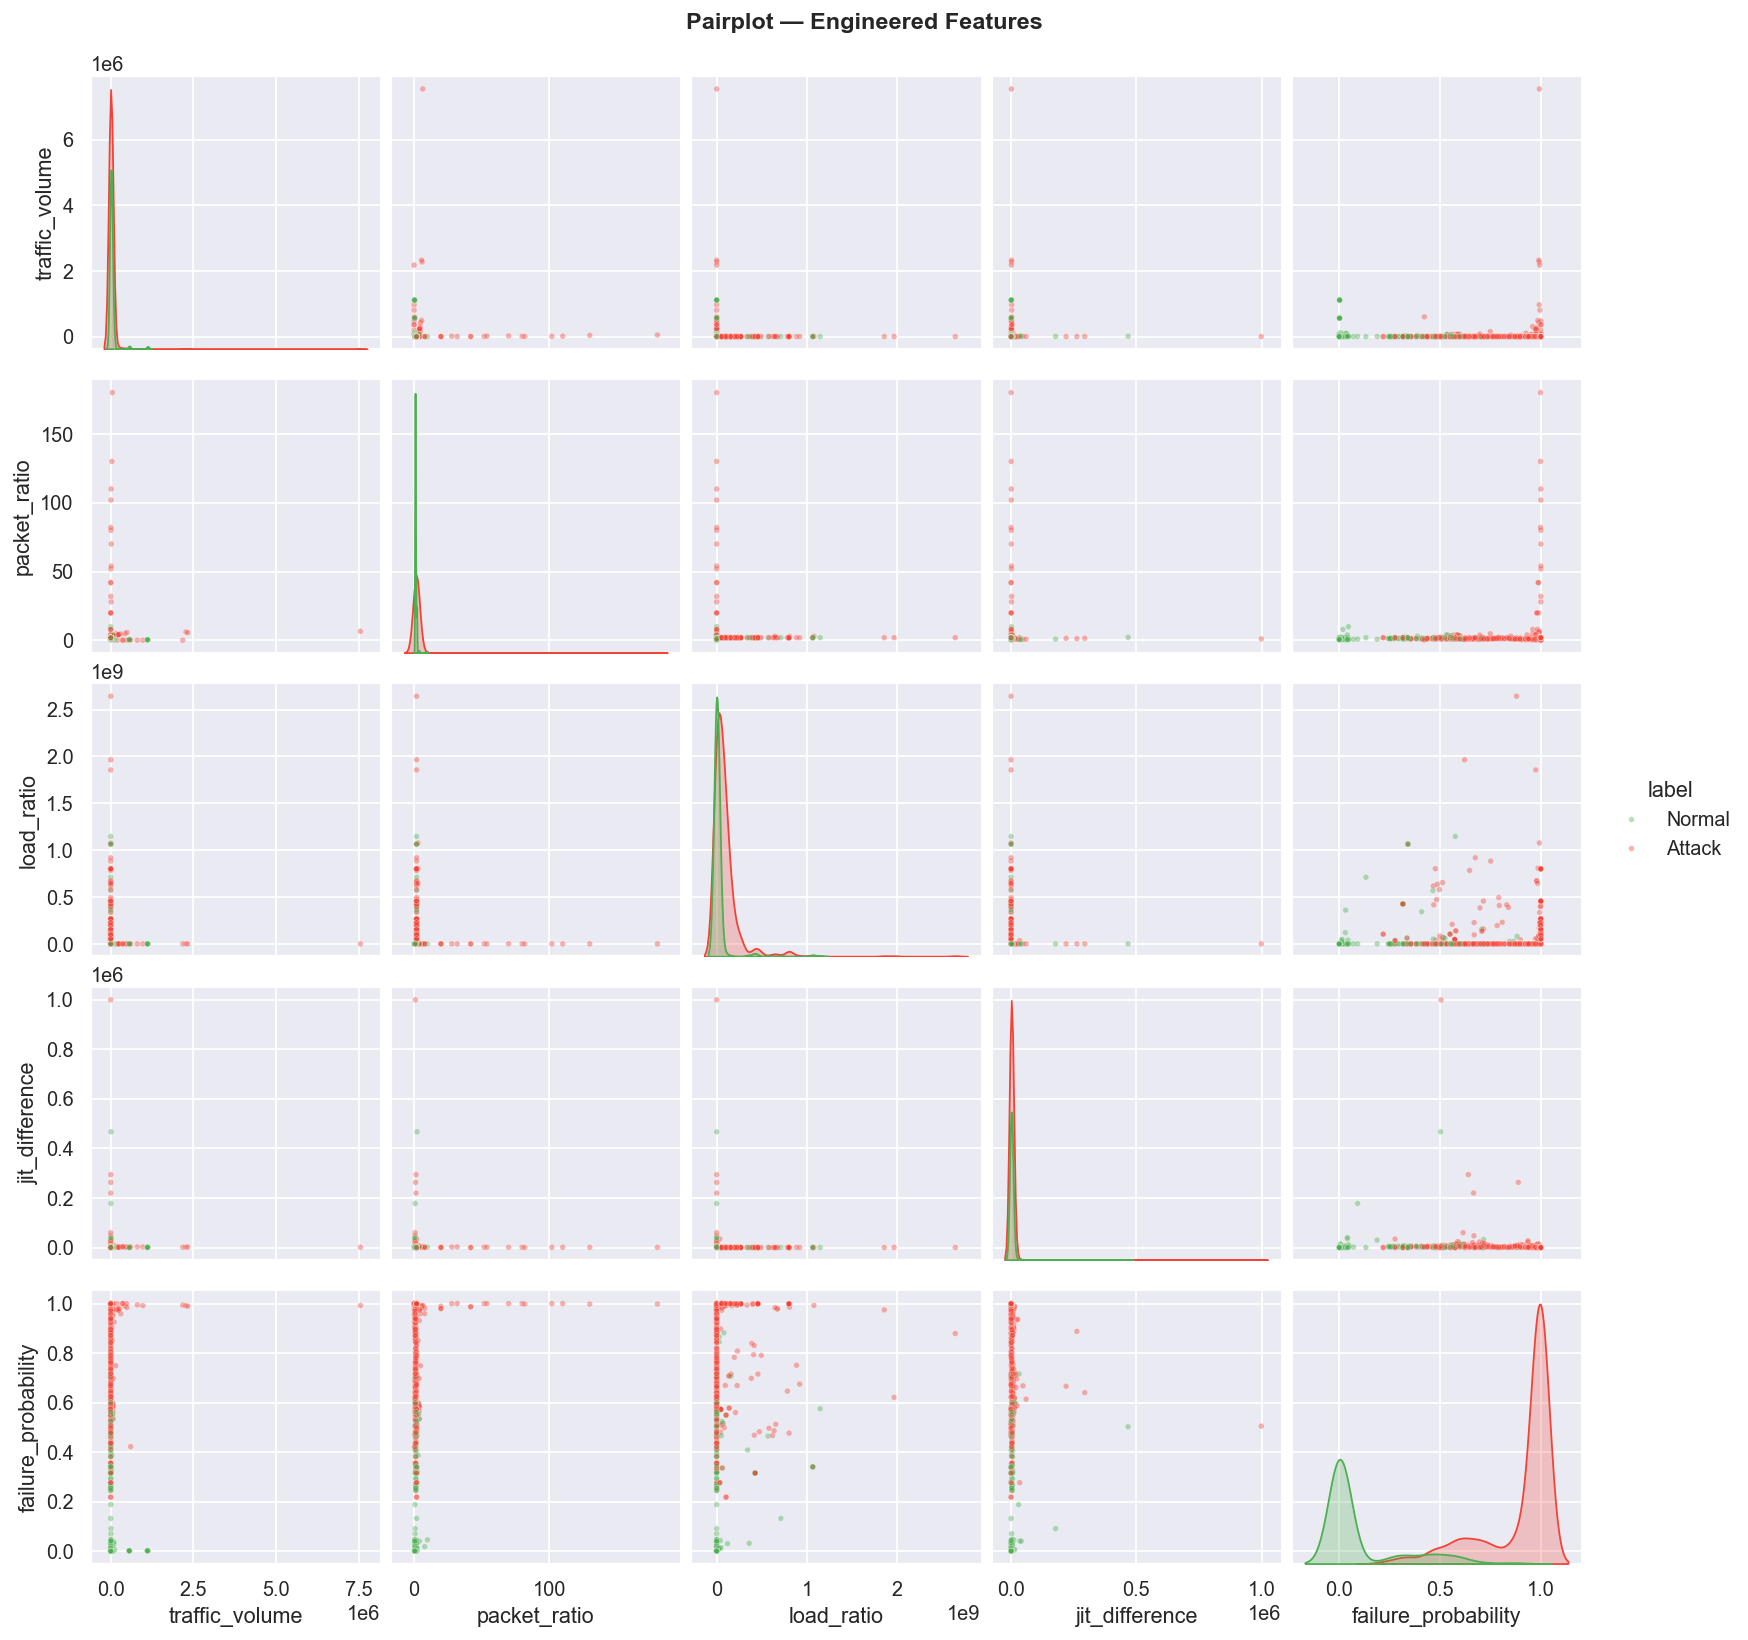

In [54]:
sample_df = data[["traffic_volume", "packet_ratio", "load_ratio",
                   "jit_difference", "failure_probability", "label"]].sample(1500, random_state=42)
sample_df["label"] = sample_df["label"].map({0: "Normal", 1: "Attack"})

g = sns.pairplot(sample_df, hue="label",
                 palette={"Normal": "#4CAF50", "Attack": "#F44336"},
                 plot_kws={"alpha": 0.4, "s": 10},
                 diag_kind="kde")
g.fig.suptitle("Pairplot — Engineered Features", y=1.01, fontsize=13, fontweight="bold")
plt.savefig("pairplot_features.png", dpi=130, bbox_inches="tight")
plt.show()


## Module 14 — Model Persistence & Deployment Readiness

In [55]:
# Save trained models and scaler for production deployment
joblib.dump(rf_model,      "network_fault_rf_model.pkl")
joblib.dump(xgb_model,     "network_fault_xgb_model.pkl")
joblib.dump(anomaly_model, "network_anomaly_iforest.pkl")
joblib.dump(scaler,        "feature_scaler.pkl")

print("Models saved:")
print("  network_fault_rf_model.pkl")
print("  network_fault_xgb_model.pkl")
print("  network_anomaly_iforest.pkl")
print("  feature_scaler.pkl")
print()
print("Deployment options:")
print("  FastAPI  -> POST /predict endpoint accepting JSON telemetry")
print("  Docker   -> containerize with requirements.txt + uvicorn")
print("  AWS      -> Lambda + API Gateway or Elastic Beanstalk")


Models saved:
  network_fault_rf_model.pkl
  network_fault_xgb_model.pkl
  network_anomaly_iforest.pkl
  feature_scaler.pkl

Deployment options:
  FastAPI  -> POST /predict endpoint accepting JSON telemetry
  Docker   -> containerize with requirements.txt + uvicorn
  AWS      -> Lambda + API Gateway or Elastic Beanstalk


In [56]:
# Minimal FastAPI deployment template (reference — do not run in notebook)
FASTAPI_TEMPLATE = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np, pandas as pd

app    = FastAPI(title="Network Fault Prediction API")
model  = joblib.load("network_fault_rf_model.pkl")
scaler = joblib.load("feature_scaler.pkl")

ML_FEATURES = [
    "dur","sbytes","dbytes","sttl","dttl","sload","dload","spkts","dpkts",
    "traffic_volume","packet_ratio","load_ratio","ttl_difference",
    "byte_ratio","pkt_mean_diff","interarrival_sum"
]

class TelemetryRecord(BaseModel):
    dur: float; sbytes: float; dbytes: float
    sttl: float; dttl: float; sload: float; dload: float
    spkts: float; dpkts: float; sinpkt: float; dinpkt: float
    smean: float; dmean: float

@app.post("/predict")
def predict(record: TelemetryRecord):
    df = pd.DataFrame([record.dict()])
    df["traffic_volume"] = df["sbytes"] + df["dbytes"]
    df["packet_ratio"]   = df["spkts"] / (df["dpkts"] + 1)
    df["load_ratio"]     = df["sload"] / (df["dload"] + 1)
    df["ttl_difference"] = abs(df["sttl"] - df["dttl"])
    df["byte_ratio"]     = df["sbytes"] / (df["dbytes"] + 1)
    df["pkt_mean_diff"]  = abs(df["smean"] - df["dmean"])
    df["interarrival_sum"] = df["sinpkt"] + df["dinpkt"]
    X = scaler.transform(df[ML_FEATURES])
    prob = model.predict_proba(X)[0][1]
    return {"failure_probability": round(float(prob), 4),
            "risk_level": "CRITICAL" if prob >= 0.7 else "HIGH" if prob >= 0.45 else "NORMAL"}
'''

print("FastAPI deployment template ready.")
print("Run with: uvicorn app:app --host 0.0.0.0 --port 8000")


FastAPI deployment template ready.
Run with: uvicorn app:app --host 0.0.0.0 --port 8000


## Project Summary

In [57]:
print("=" * 65)
print("  AI-DRIVEN NETWORK FAULT PREDICTION PLATFORM — SUMMARY")
print("=" * 65)

rf_auc  = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)
rf_acc  = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
n_crit  = (data["risk_level"] == "CRITICAL").sum()
n_high  = (data["risk_level"] == "HIGH").sum()

print(f"Dataset          : UNSW-NB15 (real network telemetry)")
print(f"Samples          : {len(data):,}")
print(f"Features         : {len(ml_features)} (13 raw + 7 engineered)")
print(f"Anomaly Detection:")
print(f"  Isolation Forest anomalies : {data['anomaly'].sum():,}")
print(f"Failure Prediction:")
print(f"  Random Forest  Accuracy={rf_acc:.4f}   ROC-AUC={rf_auc:.4f}")
print(f"  XGBoost        Accuracy={xgb_acc:.4f}   ROC-AUC={xgb_auc:.4f}")
print(f"Graph Analysis   : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  Most critical  : {max(graph_anomaly_scores, key=graph_anomaly_scores.get)}")
print(f"Streaming        : {len(df_stream)} records processed in real-time simulation")
print(f"Risk Assessment:")
print(f"  CRITICAL alerts : {n_crit:,}")
print(f"  HIGH alerts     : {n_high:,}")
print(f"Models saved for FastAPI deployment.")
print("Project Capabilities:")
for cap in [
    "Real network dataset (UNSW-NB15)",
    "Isolation Forest + One-Class SVM anomaly detection",
    "Random Forest + XGBoost failure prediction",
    "Feature engineering (7 derived network metrics)",
    "Graph topology analysis with centrality metrics",
    "Real-time streaming pipeline simulation",
    "Risk scoring system (anomaly + prediction + graph)",
    "Self-healing recommendation engine (AIOps-style)",
    "Full monitoring dashboard with 8 visualization panels",
    "Model persistence and FastAPI deployment template",
]:
    print(f"  [x] {cap}")
print("=" * 65)


  AI-DRIVEN NETWORK FAULT PREDICTION PLATFORM — SUMMARY
Dataset          : UNSW-NB15 (real network telemetry)
Samples          : 175,341
Features         : 7 (13 raw + 7 engineered)
Anomaly Detection:
  Isolation Forest anomalies : 8,733
Failure Prediction:
  Random Forest  Accuracy=0.9371   ROC-AUC=0.9874
  XGBoost        Accuracy=0.9346   ROC-AUC=0.9882
Graph Analysis   : 14 nodes, 27 edges
  Most critical  : Switch-2
Streaming        : 200 records processed in real-time simulation
Risk Assessment:
  CRITICAL alerts : 3,739
  HIGH alerts     : 93,667
Models saved for FastAPI deployment.
Project Capabilities:
  [x] Real network dataset (UNSW-NB15)
  [x] Isolation Forest + One-Class SVM anomaly detection
  [x] Random Forest + XGBoost failure prediction
  [x] Feature engineering (7 derived network metrics)
  [x] Graph topology analysis with centrality metrics
  [x] Real-time streaming pipeline simulation
  [x] Risk scoring system (anomaly + prediction + graph)
  [x] Self-healing recomme